In [1]:
import torch 
import torch.nn as nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
image_path = []
labels = []

for i in os.listdir("afhq"):
    for label in os.listdir(f"afhq/{i}"):
        for image in os.listdir(f"afhq/{i}/{label}"):
            image_path.append(f"afhq/{i}/{label}/{image}")
            labels.append(label)

df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
df.head()

,image_path,labels
0,afhq/train/cat/flickr_cat_000002.jpg,cat
1,afhq/train/cat/flickr_cat_000003.jpg,cat
2,afhq/train/cat/flickr_cat_000004.jpg,cat
3,afhq/train/cat/flickr_cat_000005.jpg,cat
4,afhq/train/cat/flickr_cat_000006.jpg,cat


In [3]:
df['labels'].unique()

<StringArray>
['cat', 'dog', 'wild']
Length: 3, dtype: str

In [4]:
train = df.sample(frac = 0.7)
test = df.drop(train.index)

val = test.sample(frac = 0.5)
test = df.drop(val.index)

print(f"train shape : {train.shape}")
print(f"test shape : {test.shape}")
print(f"validation shape : {val.shape}")

train shape : (11291, 2)
test shape : (13710, 2)
validation shape : (2420, 2)


In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(df["labels"])

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [6]:
class data(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(df["labels"]))

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx, 0]
        label = self.labels[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label 

In [7]:
train_data = data(df = train,
                 transform = transform)

test_data = data(df = test,
                 transform = transform)

val_data = data(df = val,
                 transform = transform)

findfont: Failed to find font weight medium, now using 400.


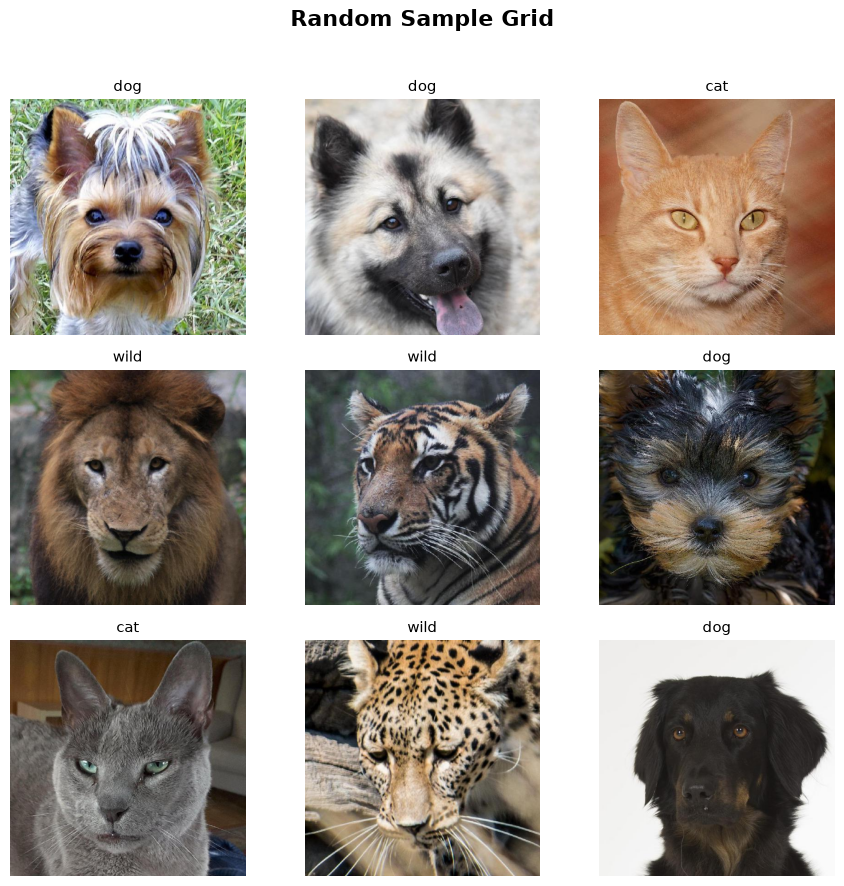

In [8]:
nrows, ncols = 3, 3
samples = df.sample(n=nrows * ncols).reset_index(drop=True)

fig, axarr = plt.subplots(nrows, ncols, figsize=(9, 9))
fig.suptitle("Random Sample Grid", fontsize=16, fontweight="bold", y=0.98)

for i in range(nrows * ncols):
    row, col = divmod(i, ncols)
    ax = axarr[row, col]

    img_path = samples.loc[i, "image_path"]
    label = samples.loc[i, "labels"]

    img = Image.open(img_path).convert("RGB")

    ax.imshow(img)
    ax.set_title(label, fontsize=11, fontweight="medium", pad=6)
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [9]:
LR = 1e-4
BATCH = 16
EPOCHS = 5

In [10]:
train_loader = DataLoader(train_data, batch_size=BATCH, shuffle=True)

test_loader = DataLoader(test_data, batch_size=BATCH, shuffle=False)

val_loader = DataLoader(val_data, batch_size=BATCH, shuffle=True)

In [11]:
class Zen(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self.pooling = nn.MaxPool2d(2, 2)

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear = nn.Linear(128*16*16, 128)
        self.output = nn.Linear(128 , len(df['labels'].unique()))
    def forward(self, X):
        X = self.conv1(X)
        X = self.pooling(X)
        X = self.relu(X)

        X = self.conv2(X)
        X = self.pooling(X)
        X = self.relu(X)

        X = self.conv3(X)
        X = self.pooling(X)
        X = self.relu(X)

        X = self.flatten(X)
        X = self.linear(X)
        X = self.output(X)

        return X

In [12]:
model = Zen().to(device)
from torchinfo import summary
summary(model, input_size=(1, 3, 128, 128))  # (batch, channels, H, W)

Layer (type:depth-idx)                   Output Shape              Param #
Zen                                      [1, 3]                    --
├─Conv2d: 1-1                            [1, 32, 128, 128]         896
├─MaxPool2d: 1-2                         [1, 32, 64, 64]           --
├─ReLU: 1-3                              [1, 32, 64, 64]           --
├─Conv2d: 1-4                            [1, 64, 64, 64]           18,496
├─MaxPool2d: 1-5                         [1, 64, 32, 32]           --
├─ReLU: 1-6                              [1, 64, 32, 32]           --
├─Conv2d: 1-7                            [1, 128, 32, 32]          73,856
├─MaxPool2d: 1-8                         [1, 128, 16, 16]          --
├─ReLU: 1-9                              [1, 128, 16, 16]          --
├─Flatten: 1-10                          [1, 32768]                --
├─Linear: 1-11                           [1, 128]                  4,194,432
├─Linear: 1-12                           [1, 3]                    38

In [13]:
loss_fn = nn.CrossEntropyLoss()
optim = Adam(params=model.parameters(), lr=LR)

In [14]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
    total_acc_train, total_loss_train, total_acc_val, total_loss_val = 0, 0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optim.zero_grad()

        outputs = model(inputs)
        train_loss = loss_fn(outputs, labels)
        total_loss_train += train_loss.item()
        train_loss.backward()

        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc
        optim.step()

    with torch.inference_mode():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            val_loss = loss_fn(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_val += val_acc

    train_loss_avg = round(total_loss_train / len(train_loader), 4)
    val_loss_avg = round(total_loss_val / len(val_loader), 4)
    train_acc_avg = round(total_acc_train / len(train_data) * 100, 4)
    val_acc_avg = round(total_acc_val / len(val_data) * 100, 4)

    total_loss_train_plot.append(train_loss_avg)
    total_loss_val_plot.append(val_loss_avg)
    total_acc_train_plot.append(train_acc_avg)
    total_acc_val_plot.append(val_acc_avg)

    print(f'''
        Epoch : {epoch} | train loss : {train_loss_avg}
        train accuracy : {train_acc_avg}
        validation loss : {val_loss_avg}
        validation accuracy : {val_acc_avg}
    ''')


        Epoch : 0 | train loss : 0.4886
        train accuracy : 79.1781
        validation loss : 0.3041
        validation accuracy : 89.0083
    

        Epoch : 1 | train loss : 0.1981
        train accuracy : 92.8173
        validation loss : 0.1537
        validation accuracy : 94.7107
    

        Epoch : 2 | train loss : 0.1286
        train accuracy : 95.2794
        validation loss : 0.1793
        validation accuracy : 93.6364
    

        Epoch : 3 | train loss : 0.0936
        train accuracy : 96.5902
        validation loss : 0.132
        validation accuracy : 95.2066
    

        Epoch : 4 | train loss : 0.069
        train accuracy : 97.5556
        validation loss : 0.1197
        validation accuracy : 95.9504
    


In [15]:
with torch.inference_mode():
    total_loss, total_acc = 0, 0
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        preds = model(inputs)
        loss = loss_fn(preds, labels)
        total_loss += loss.item()

        acc = (torch.argmax(preds, axis=1) == labels).sum().item()
        total_acc += acc

test_loss_avg = round(total_loss / len(test_loader), 4)
test_acc_avg = round(total_acc / len(test_data) * 100, 4)

print(f'Test loss: {test_loss_avg} | Test accuracy: {test_acc_avg}%')

Test loss: 0.0662 | Test accuracy: 97.8775%


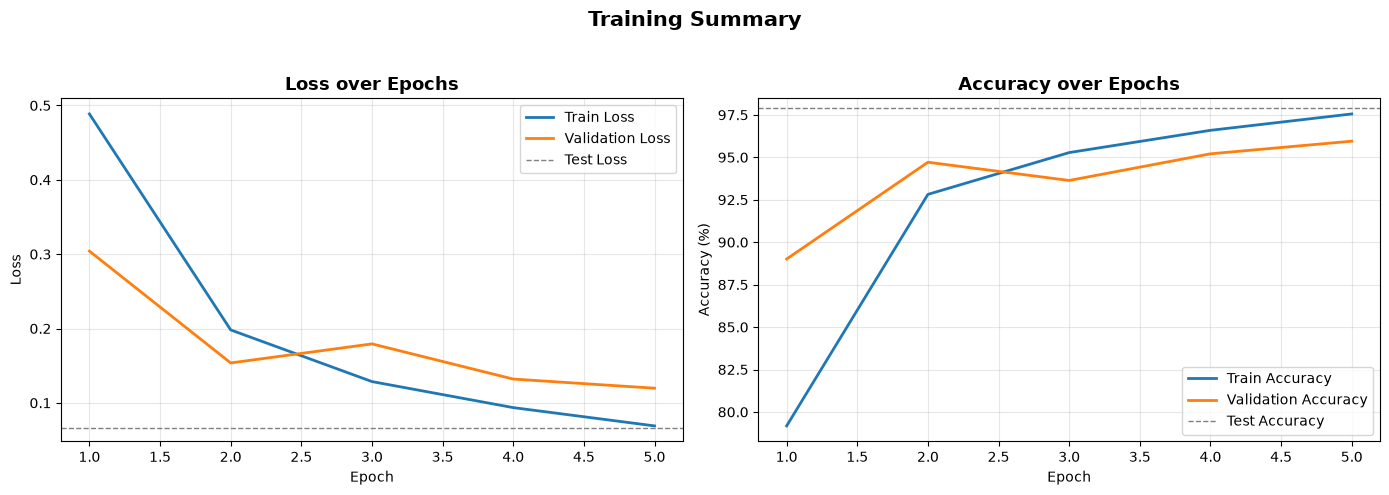

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(total_loss_train_plot) + 1)

# --- Loss plot ---
axs[0].plot(epochs_range, total_loss_train_plot, label='Train Loss', linewidth=2)
axs[0].plot(epochs_range, total_loss_val_plot, label='Validation Loss', linewidth=2)
axs[0].axhline(test_loss_avg, color='gray', linestyle='--', linewidth=1, label='Test Loss')
axs[0].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# --- Accuracy plot ---
axs[1].plot(epochs_range, total_acc_train_plot, label='Train Accuracy', linewidth=2)
axs[1].plot(epochs_range, total_acc_val_plot, label='Validation Accuracy', linewidth=2)
axs[1].axhline(test_acc_avg, color='gray', linestyle='--', linewidth=1, label='Test Accuracy')
axs[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

fig.suptitle('Training Summary', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [20]:
def predict(img_path, model, transform, label_encoder, device):
    model.eval()

    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img)
    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.inference_mode():
        output = model(img_tensor)
        pred_idx = torch.argmax(output, axis=1).item()

    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    plt.close('all')
    fig = plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(pred_label, fontsize=14, fontweight='bold')
    plt.axis('off')
    display(fig)   # explicit display, safer inside functions than plt.show()
    plt.close(fig)

    return pred_label

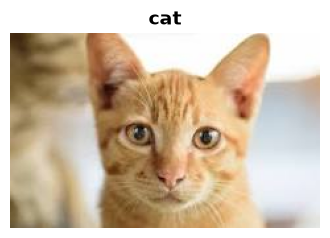

'cat'

In [21]:
predict('test/cat1.jpg', model, transform, label_encoder, device)

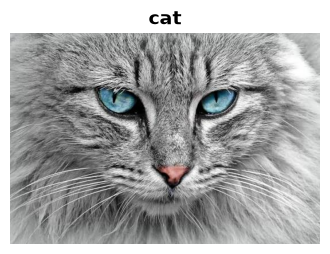

'cat'

In [22]:
predict('test/cat2.jpg', model, transform, label_encoder, device)

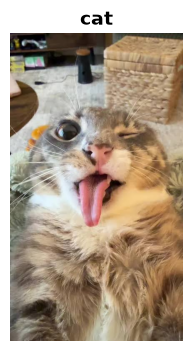

'cat'

In [23]:
predict('test/cat3.jpg', model, transform, label_encoder, device)

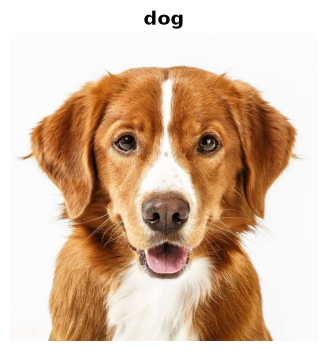

'dog'

In [24]:
predict('test/dog1.jpg', model, transform, label_encoder, device)

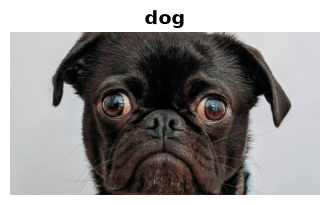

'dog'

In [25]:
predict('test/dog2.jpg', model, transform, label_encoder, device)

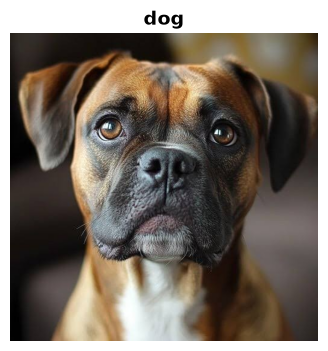

'dog'

In [26]:
predict('test/dog3.jpg', model, transform, label_encoder, device)

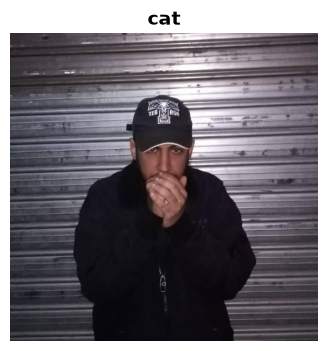

'cat'

In [28]:
predict('test/cheb terro.jpg', model, transform, label_encoder, device)

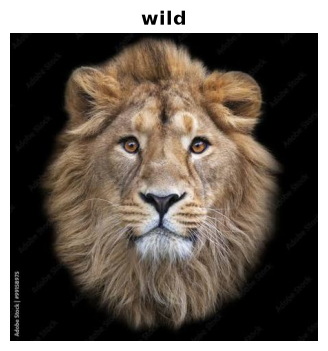

'wild'

In [30]:
predict('test/wild1.jpg', model, transform, label_encoder, device)

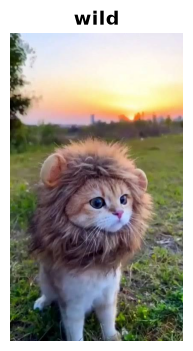

'wild'

In [31]:
predict('test/wild2.jpg', model, transform, label_encoder, device)